# ResNet-18 L1 Unstructured Pruning — CIFAR-10

Applies `torch.nn.utils.prune.l1_unstructured` to all Conv2d layers at 20%, 40%, and 60% sparsity,
fine-tunes for 5 epochs to recover accuracy, then plots sparsity vs. top-1 accuracy.

**Setup:** Upload `best_resnet18_cifar10.pth` and `resnet.py` using the Kaggle data panel before running.

Reference: Han et al. (2015) — *Learning both Weights and Connections for Efficient Neural Networks*
(https://arxiv.org/abs/1506.02626)

## 1. Imports and config

In [1]:
import copy
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader


RESNET_PY_DIR = "/kaggle/input/datasets/mendelowitzadi/resent-input"          # folder containing resnet.py
CHECKPOINT_PATH = "/kaggle/input/datasets/mendelowitzadi/resent-input/best_resnet18_cifar10 (1).pth"
DATA_DIR = "/kaggle/working/data"                          # CIFAR-10 downloads here
PLOT_PATH = "/kaggle/working/sparsity_accuracy.png"

sys.path.insert(0, RESNET_PY_DIR)
from resnet import resnet18 as custom_resnet18

SPARSITY_LEVELS = [0.0, 0.2, 0.4, 0.6]
FINE_TUNE_EPOCHS = 5
BATCH_SIZE = 128
FINE_TUNE_LR = 1e-3
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


## 2. Data loaders

In [2]:
def get_loaders(batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """Return (train_loader, test_loader) for CIFAR-10."""
    train_transform = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    test_transform = T.Compose([T.ToTensor(), T.Normalize(CIFAR10_MEAN, CIFAR10_STD)])

    train_set = torchvision.datasets.CIFAR10(DATA_DIR, train=True,  download=True, transform=train_transform)
    test_set  = torchvision.datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=test_transform)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader

train_loader, test_loader = get_loaders()
print(f"Train batches: {len(train_loader)}  Test batches: {len(test_loader)}")

100%|██████████| 170M/170M [00:02<00:00, 80.9MB/s] 


Train batches: 391  Test batches: 79


## 3. Model loading

In [3]:
def load_base_model(checkpoint_path: str) -> nn.Module:
    """Load the CIFAR-10 adapted ResNet-18 (3x3 conv1, no maxpool)."""
    model = custom_resnet18(num_classes=10)
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    state = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    return model.to(device)

base_model = load_base_model(CHECKPOINT_PATH)
print("Checkpoint loaded.")

Checkpoint loaded.


## 4. Pruning and fine-tuning utilities

In [4]:
def apply_l1_unstructured(model: nn.Module, sparsity: float) -> None:
    """Apply L1 unstructured pruning to every Conv2d weight tensor in-place.

    Adds weight_orig and weight_mask buffers to each Conv2d. The forward
    pass computes weight = weight_orig * weight_mask, zeroing the lowest-
    magnitude weights. The mask is fixed for the duration of fine-tuning.
    """
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            prune.l1_unstructured(module, name="weight", amount=sparsity)


def remove_pruning_masks(model: nn.Module) -> None:
    """Make pruning permanent: removes weight_orig / weight_mask reparametrizations."""
    for module in model.modules():
        if isinstance(module, nn.Conv2d) and prune.is_pruned(module):
            prune.remove(module, "weight")


def conv_sparsity(model: nn.Module) -> float:
    """Return fraction of zero weights across all Conv2d layers."""
    total = zeros = 0
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            zeros += (module.weight == 0).sum().item()
            total += module.weight.numel()
    return zeros / total if total > 0 else 0.0


def evaluate_top1(model: nn.Module, loader: DataLoader) -> float:
    """Return top-1 accuracy (%)."""
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += model(x).argmax(dim=1).eq(y).sum().item()
            total   += y.size(0)
    return 100.0 * correct / total


def fine_tune(model: nn.Module, loader: DataLoader, epochs: int) -> None:
    """Fine-tune with pruning masks fixed. Uses SGD with a small recovery LR."""
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=FINE_TUNE_LR, momentum=0.9, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        total_loss = n = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            n          += x.size(0)
        print(f"    epoch {epoch}/{epochs}  loss={total_loss / n:.4f}")

print("Utilities defined.")

Utilities defined.


## 5. Run pruning experiments

In [5]:
@dataclass
class PruningResult:
    sparsity_target: float
    sparsity_actual: float
    top1_before: float
    top1_after: float


results: list[PruningResult] = []

for sparsity in SPARSITY_LEVELS:
    print(f"\n{'='*50}")
    print(f"Sparsity: {sparsity * 100:.0f}%")

    model = copy.deepcopy(base_model)

    if sparsity == 0.0:
        acc = evaluate_top1(model, test_loader)
        print(f"  Baseline top-1: {acc:.2f}%")
        results.append(PruningResult(0.0, 0.0, acc, acc))
        continue

    apply_l1_unstructured(model, sparsity)
    acc_before = evaluate_top1(model, test_loader)
    actual     = conv_sparsity(model)
    print(f"  Actual sparsity: {actual * 100:.1f}%  top-1 before fine-tuning: {acc_before:.2f}%")

    print(f"  Fine-tuning for {FINE_TUNE_EPOCHS} epochs...")
    fine_tune(model, train_loader, FINE_TUNE_EPOCHS)
    remove_pruning_masks(model)

    acc_after = evaluate_top1(model, test_loader)
    print(f"  Top-1 after fine-tuning: {acc_after:.2f}%")

    results.append(PruningResult(sparsity, actual, acc_before, acc_after))


Sparsity: 0%
  Baseline top-1: 93.13%

Sparsity: 20%
  Actual sparsity: 20.0%  top-1 before fine-tuning: 93.16%
  Fine-tuning for 5 epochs...
    epoch 1/5  loss=0.0205
    epoch 2/5  loss=0.0204
    epoch 3/5  loss=0.0190
    epoch 4/5  loss=0.0187
    epoch 5/5  loss=0.0181
  Top-1 after fine-tuning: 93.42%

Sparsity: 40%
  Actual sparsity: 40.0%  top-1 before fine-tuning: 92.95%
  Fine-tuning for 5 epochs...
    epoch 1/5  loss=0.0222
    epoch 2/5  loss=0.0213
    epoch 3/5  loss=0.0206
    epoch 4/5  loss=0.0193
    epoch 5/5  loss=0.0185
  Top-1 after fine-tuning: 93.38%

Sparsity: 60%
  Actual sparsity: 60.0%  top-1 before fine-tuning: 91.53%
  Fine-tuning for 5 epochs...
    epoch 1/5  loss=0.0272
    epoch 2/5  loss=0.0260
    epoch 3/5  loss=0.0249
    epoch 4/5  loss=0.0228
    epoch 5/5  loss=0.0223
  Top-1 after fine-tuning: 93.27%


## 6. Results table

In [6]:
col = 20
header = (
    f"{'Target sparsity':>{col}} {'Actual sparsity':>{col}}"
    f" {'Top-1 before (%)':>{col}} {'Top-1 after (%)':>{col}}"
)
print(header)
print("-" * len(header))
for r in results:
    print(
        f"{r.sparsity_target * 100:>{col}.0f}%"
        f" {r.sparsity_actual * 100:>{col}.1f}%"
        f" {r.top1_before:>{col}.2f}"
        f" {r.top1_after:>{col}.2f}"
    )

     Target sparsity      Actual sparsity     Top-1 before (%)      Top-1 after (%)
-----------------------------------------------------------------------------------
                   0%                  0.0%                93.13                93.13
                  20%                 20.0%                93.16                93.42
                  40%                 40.0%                92.95                93.38
                  60%                 60.0%                91.53                93.27


## 7. Sparsity vs accuracy plot

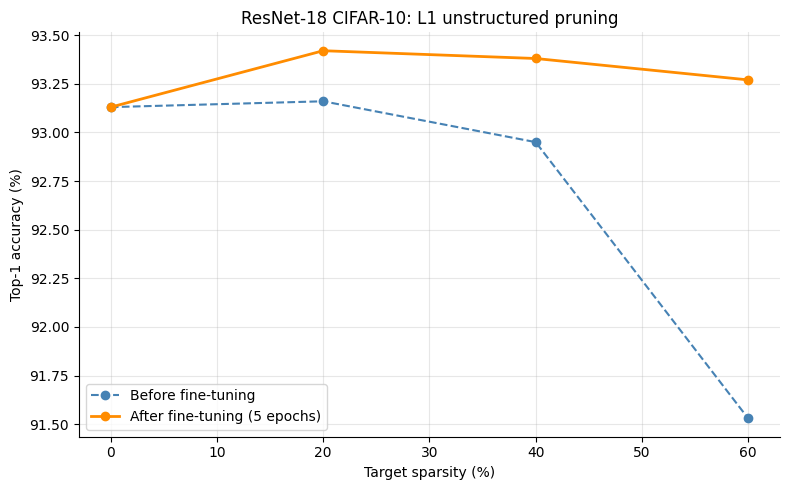

Plot saved to /kaggle/working/sparsity_accuracy.png


In [7]:
targets = [r.sparsity_target * 100 for r in results]
before  = [r.top1_before for r in results]
after   = [r.top1_after  for r in results]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(targets, before, "o--", color="steelblue",  label="Before fine-tuning")
ax.plot(targets, after,  "o-",  color="darkorange", linewidth=2,
        label=f"After fine-tuning ({FINE_TUNE_EPOCHS} epochs)")
ax.set_xlabel("Target sparsity (%)")
ax.set_ylabel("Top-1 accuracy (%)")
ax.set_title("ResNet-18 CIFAR-10: L1 unstructured pruning")
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved to {PLOT_PATH}")